In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [255]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [256]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [257]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isnull().sum()

np.int64(11)

In [258]:
df = df.dropna(subset=["TotalCharges"])

df["TotalCharges"].isnull().sum()

np.int64(0)

In [259]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

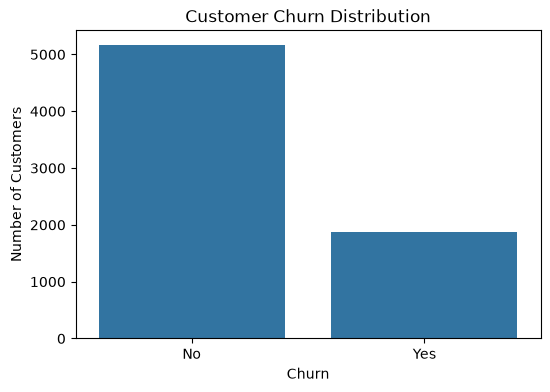

In [260]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

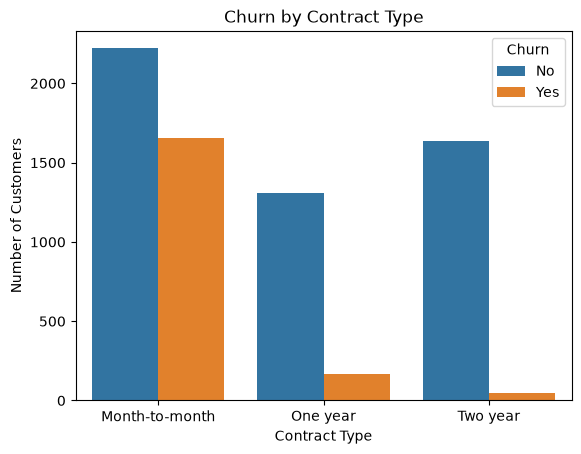

In [261]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

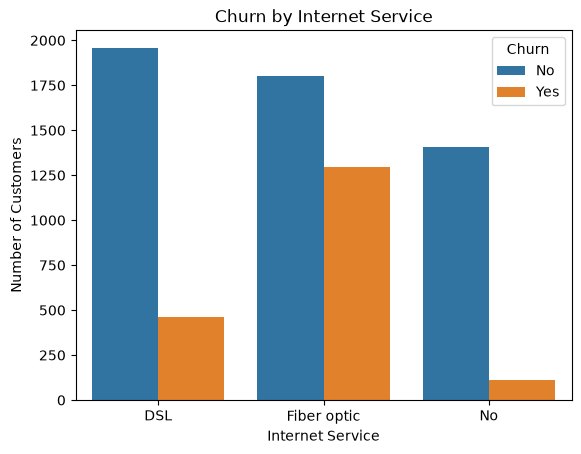

In [262]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

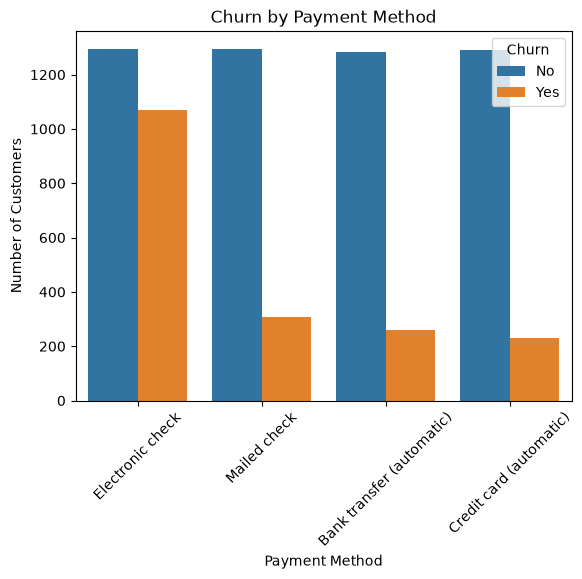

In [263]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [264]:
# Separate input features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Remove customer ID because it has no predictive meaning
X = X.drop("customerID", axis=1)

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

# Display the processed data
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [265]:
y = y.map({'No': 0, 'Yes': 1})

y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [266]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [267]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression completed successfully!")

Logistic Regression completed successfully!


c:\Users\Shree vidya N\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [268]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression completed successfully!")

Logistic Regression completed successfully!


In [269]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

accuracy_log = accuracy_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1])

print("Logistic Regression Results")
print("Accuracy:", accuracy_log)
print("Recall:", recall_log)
print("ROC-AUC:", roc_auc_log)

Logistic Regression Results
Accuracy: 0.8038379530916845
Recall: 0.5748663101604278
ROC-AUC: 0.8356727976766699


In [270]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest completed successfully!")

Random Forest completed successfully!


In [271]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print("Random Forest Results")
print("Accuracy:", accuracy_rf)
print("Recall:", recall_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest Results
Accuracy: 0.7896233120113717
Recall: 0.5187165775401069
ROC-AUC: 0.8164903116927489


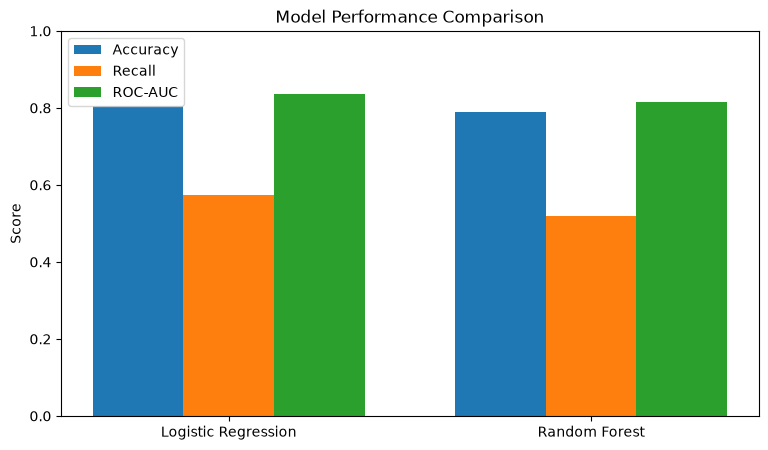

In [272]:
models = ['Logistic Regression', 'Random Forest']

accuracy_scores = [accuracy_log, accuracy_rf]
recall_scores = [recall_log, recall_rf]
roc_auc_scores = [roc_auc_log, roc_auc_rf]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - width, accuracy_scores, width, label='Accuracy')
plt.bar(x, recall_scores, width, label='Recall')
plt.bar(x + width, roc_auc_scores, width, label='ROC-AUC')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.legend()

plt.show()

In [273]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

TotalCharges                      0.191435
tenure                            0.171020
MonthlyCharges                    0.168400
InternetService_Fiber optic       0.039481
PaymentMethod_Electronic check    0.037416
Contract_Two year                 0.030529
gender_Male                       0.029332
OnlineSecurity_Yes                0.028157
PaperlessBilling_Yes              0.025536
TechSupport_Yes                   0.024114
dtype: float64

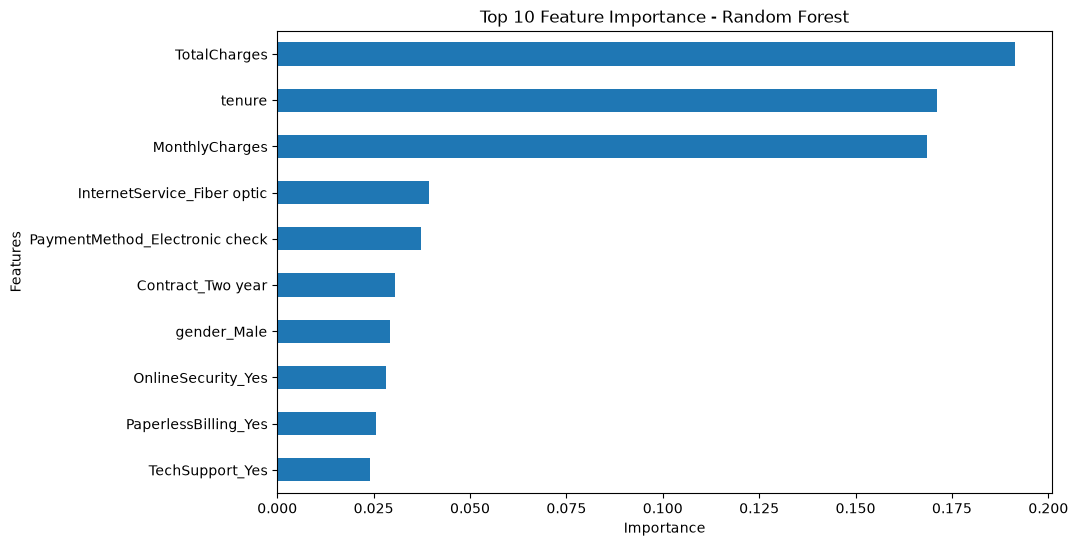

In [274]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.show()

In [275]:
new_customer = X_test.iloc[[0]]

prediction = rf_model.predict(new_customer)

if prediction[0] == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")

Prediction: Customer is likely to STAY


In [276]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_log, accuracy_rf],
    'Recall': [recall_log, recall_rf],
    'ROC-AUC': [roc_auc_log, roc_auc_rf]
})

results

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.803838,0.574866,0.835673
1,Random Forest,0.789623,0.518717,0.816490


# Conclusion

This project successfully developed a Customer Churn Prediction system using machine learning.

Two classification models were implemented:

- Logistic Regression
- Random Forest

The models were evaluated using Accuracy, Recall, and ROC-AUC.

### Model Performance

Logistic Regression achieved:
- Accuracy: 80.38%
- Recall: 57.49%
- ROC-AUC: 83.57%

Random Forest achieved:
- Accuracy: 78.96%
- Recall: 51.87%
- ROC-AUC: 81.65%

Based on the evaluation results, Logistic Regression performed better than Random Forest for this dataset.

Feature importance analysis showed that TotalCharges, tenure, and MonthlyCharges were among the most influential features for predicting customer churn.

The final model was also used to predict churn for an individual customer.